In [1]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Use the actual notebook working directory
nb_dir = Path.cwd()
print(f"Current notebook path: {nb_dir}")

# Optionally add the notebook dir (for local-only imports)
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))
    print(f"Added {nb_dir} to sys.path")

# Critically: add the repository root so top-level packages like 'utils' are importable
# Notebook path: /home/luky/skola/KalmanNet-main/navigation NCLT dataset/linear_velocity_integration
# Repo root is two levels up: /home/luky/skola/KalmanNet-main
repo_root = nb_dir.parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    print(f"Added {repo_root} to sys.path")

Current notebook path: /home/luky/skola/KalmanNet-main/navigation NCLT dataset/NCLT_linear_model_test
Added /home/luky/skola/KalmanNet-main/navigation NCLT dataset/NCLT_linear_model_test to sys.path
Added /home/luky/skola/KalmanNet-main to sys.path


In [2]:
import torch
import matplotlib.pyplot as plt
from utils import trainer
from utils import utils
from Systems import DynamicSystem
import Filters
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


Načítám soubor: ../ground_truth/groundtruth_2012-01-22.csv...


/tmp/ipykernel_50100/3200543427.py:21: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None, names=['time', 'x', 'y', 'z', 'r', 'p', 'h'])



✅ Data seřazena do formátu [px, vx, py, vy]. Shape: (5210, 4)
Měření vygenerována (Simulace GPS+Odo). Shape: torch.Size([5210, 4])
  -> Šum polohy (std): 26.46 m
  -> Šum rychlosti (std): 0.10 m/s
Dataset rozdělen: Train=3126, Val=1042, Test=1042


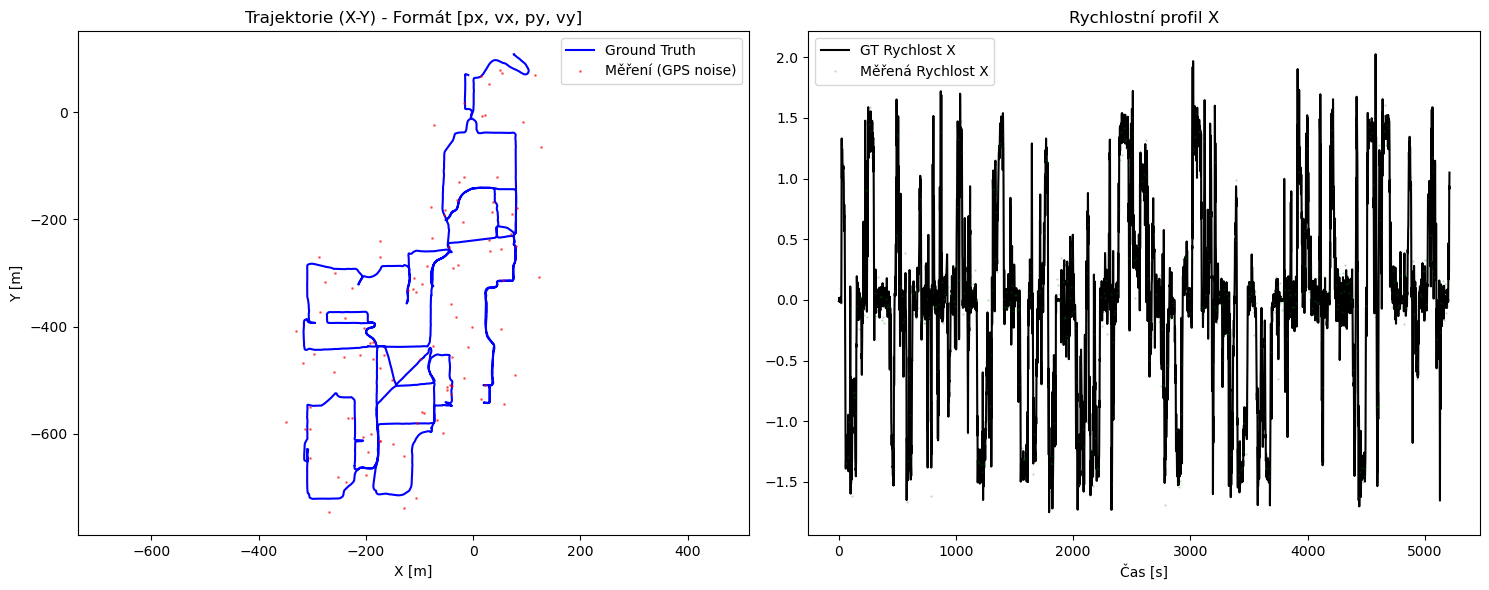

In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# === 1. KONFIGURACE ===
file_path = '../ground_truth/groundtruth_2012-01-22.csv' 
DT = 1.0  # Časový krok

# Parametry šumu pro generování trénovacích dat (Simulace měření)
# Abychom replikovali autory, musíme vygenerovat měření, která odpovídají
# jejich matici R: diag([700, 0.01, 700, 0.01]).
# Tedy: Velký šum na pozici (GPS), malý na rychlosti (Odometrie).
std_pos = np.sqrt(700.0)  # cca 26.4 metrů
std_vel = np.sqrt(0.01)   # 0.1 m/s

# === 2. NAČTENÍ A PŘÍPRAVA SUROVÝCH DAT ===
print(f"Načítám soubor: {file_path}...")
try:
    df = pd.read_csv(file_path, header=None, names=['time', 'x', 'y', 'z', 'r', 'p', 'h'])
    raw_time = df['time'].values / 1e6
    raw_time = raw_time - raw_time[0]
    raw_pos = df[['x', 'y']].values
    
    # --- Resampling (Interpolace) ---
    t_resampled = np.arange(0, raw_time[-1], DT)
    interp_func = interp1d(raw_time, raw_pos, kind='linear', axis=0, fill_value="extrapolate")
    pos_resampled = interp_func(t_resampled) # [N, 2] -> (x, y)
    
    # --- Výpočet rychlosti (Derivace) ---
    vel_resampled = np.zeros_like(pos_resampled)
    vel_resampled[1:] = (pos_resampled[1:] - pos_resampled[:-1]) / DT
    vel_resampled[0] = vel_resampled[1]
    
    # === 3. SKLÁDÁNÍ DO FORMÁTU AUTORŮ [px, vx, py, vy] ===
    # Toto je ta klíčová změna!
    # Sloupec 0: Pozice X
    # Sloupec 1: Rychlost X
    # Sloupec 2: Pozice Y
    # Sloupec 3: Rychlost Y
    
    GT_DATA = np.stack((
        pos_resampled[:, 0], # px
        vel_resampled[:, 0], # vx
        pos_resampled[:, 1], # py
        vel_resampled[:, 1]  # vy
    ), axis=1)
    
    print(f"\n✅ Data seřazena do formátu [px, vx, py, vy]. Shape: {GT_DATA.shape}")

    # === 4. KONVERZE DO PYTORCH A GENEROVÁNÍ MĚŘENÍ ===
    X_target = torch.from_numpy(GT_DATA).float()
    N_samples = X_target.shape[0]
    
    # Generování šumu měření podle specifikace autorů
    # noise_std vektor: [std_px, std_vx, std_py, std_vy]
    noise_std_vec = torch.tensor([std_pos, std_vel, std_pos, std_vel])
    
    # Y = X + Noise
    # Rozšiřujeme noise_std_vec na velikost dat
    noise = torch.randn(N_samples, 4) * noise_std_vec
    Y_measured = X_target + noise
    
    print(f"Měření vygenerována (Simulace GPS+Odo). Shape: {Y_measured.shape}")
    print(f"  -> Šum polohy (std): {std_pos:.2f} m")
    print(f"  -> Šum rychlosti (std): {std_vel:.2f} m/s")

    # === 5. ROZDĚLENÍ TRAIN / VAL / TEST ===
    n_train = int(0.6 * N_samples)
    n_val = int(0.2 * N_samples)
    n_test = N_samples - n_train - n_val
    
    train_input = Y_measured[:n_train]
    train_target = X_target[:n_train]
    
    val_input = Y_measured[n_train:n_train+n_val]
    val_target = X_target[n_train:n_train+n_val]
    
    test_input = Y_measured[n_train+n_val:]
    test_target = X_target[n_train+n_val:]
    
    print(f"Dataset rozdělen: Train={len(train_input)}, Val={len(val_input)}, Test={len(test_input)}")

    # === 6. VIZUALIZACE KONTROLY ===
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    # Pro vizualizaci musíme brát správné sloupce z nového GT_DATA
    # X=0, VX=1, Y=2, VY=3
    
    # Trajektorie (X vs Y) -> Sloupec 0 vs Sloupec 2
    ax[0].plot(GT_DATA[:, 0], GT_DATA[:, 2], 'b-', label='Ground Truth')
    # Vykreslíme i kousek měření (jen pro představu šumu), bereme jen každý 50. bod ať to není čmouha
    ax[0].plot(Y_measured[::50, 0], Y_measured[::50, 2], 'r.', markersize=2, alpha=0.5, label='Měření (GPS noise)')
    ax[0].set_title('Trajektorie (X-Y) - Formát [px, vx, py, vy]')
    ax[0].set_xlabel('X [m]')
    ax[0].set_ylabel('Y [m]')
    ax[0].axis('equal')
    ax[0].legend()
    
    # Rychlost X (VX) -> Sloupec 1
    ax[1].plot(t_resampled, GT_DATA[:, 1], 'k-', label='GT Rychlost X')
    ax[1].plot(t_resampled[::10], Y_measured[::10, 1], 'g.', markersize=1, alpha=0.3, label='Měřená Rychlost X')
    ax[1].set_title('Rychlostní profil X')
    ax[1].set_xlabel('Čas [s]')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ CHYBA: Soubor '{file_path}' nenalezen.")
except Exception as e:
    print(f"❌ CHYBA: {e}")
from state_NN_models.RecursiveKalmanNet import StateRecursiveKalmanNet

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from copy import deepcopy

def train_RKN(
    model, 
    train_loader, 
    val_loader, 
    device, 
    epochs=100, 
    lr=1e-3, 
    clip_grad=1.0, 
    early_stopping_patience=20, 
    optimizer_type=torch.optim.AdamW,
    weight_decay=1e-5,
    use_nll_loss=False
):
    if use_nll_loss and not model.returns_covariance:
        raise ValueError("Cannot use NLL Loss if model.returns_covariance is False.")

    optimizer = optimizer_type(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    best_val_loss = float('inf')
    best_val_mse_at_opt = float('inf')
    optimal_epoch = 0
    epochs_no_improve = 0
    best_model_state = None

    print(f"🚀 START RKN Training (Epochs: {epochs}, LR: {lr}, NLL Loss: {use_nll_loss})")

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        train_mse_metric_sum = 0.0

        for x_true_batch, y_meas_batch in train_loader:
            x_true_batch = x_true_batch.to(device)
            y_meas_batch = y_meas_batch.to(device)
            batch_size, seq_len, _ = x_true_batch.shape

            optimizer.zero_grad()
            model.reset(batch_size=batch_size, initial_state=x_true_batch[:, 0, :])

            predictions_x = []
            predictions_P = []

            for t in range(1, seq_len):
                y_t = y_meas_batch[:, t, :]
                
                if model.returns_covariance:
                    x_filtered_t, P_filtered_t, _ = model.step(y_t)
                    predictions_P.append(P_filtered_t)
                else:
                    x_filtered_t, _ = model.step(y_t)
                predictions_x.append(x_filtered_t)

            predicted_trajectory = torch.stack(predictions_x, dim=1)
            target_trajectory = x_true_batch[:, 1:, :]

            if use_nll_loss:
                predicted_cov_trajectory = torch.stack(predictions_P, dim=1)
                I_eps = torch.eye(model.state_dim, device=device).view(1, 1, model.state_dim, model.state_dim) * 1e-6
                safe_cov = predicted_cov_trajectory + I_eps
                
                error = (target_trajectory - predicted_trajectory).unsqueeze(-1)
                flat_cov = safe_cov.view(-1, model.state_dim, model.state_dim)
                flat_err = error.view(-1, model.state_dim, 1)
                
                try:
                    cov_inv = torch.linalg.pinv(flat_cov, hermitian=True)
                    mahalanobis = torch.bmm(torch.bmm(flat_err.transpose(1, 2), cov_inv), flat_err).squeeze()
                    sign, logdet = torch.linalg.slogdet(flat_cov)
                    loss = 0.5 * (mahalanobis + logdet).mean()
                except torch._C._LinAlgError:
                    loss = F.mse_loss(predicted_trajectory, target_trajectory)
            else:
                loss = F.mse_loss(predicted_trajectory, target_trajectory)

            loss.backward()
            if clip_grad > 0:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            
            train_loss_sum += loss.item()
            with torch.no_grad():
                train_mse_metric_sum += F.mse_loss(predicted_trajectory, target_trajectory).item()

        scheduler.step()
        avg_train_loss = train_loss_sum / len(train_loader)
        avg_train_mse = train_mse_metric_sum / len(train_loader)

        # === Validation Phase ===
        model.eval()
        val_loss_sum = 0.0
        val_mse_sum = 0.0
        val_anees_sum = 0.0  # <--- Sběr ANEES
        
        with torch.no_grad():
            for x_true_val, y_meas_val in val_loader:
                x_true_val = x_true_val.to(device)
                y_meas_val = y_meas_val.to(device)
                batch_size_val, seq_len_val, _ = x_true_val.shape

                model.reset(batch_size=batch_size_val, initial_state=x_true_val[:, 0, :])
                
                val_predictions_x = []
                val_predictions_P = []

                for t in range(1, seq_len_val):
                    y_t_val = y_meas_val[:, t, :]
                    if model.returns_covariance:
                        x_filtered_t_val, P_filtered_t_val, _ = model.step(y_t_val)
                        val_predictions_P.append(P_filtered_t_val)
                    else:
                        x_filtered_t_val, _ = model.step(y_t_val)
                    val_predictions_x.append(x_filtered_t_val)
                    
                predicted_val_trajectory = torch.stack(val_predictions_x, dim=1)
                target_val_trajectory = x_true_val[:, 1:, :]

                if use_nll_loss:
                    predicted_cov_val = torch.stack(val_predictions_P, dim=1)
                    safe_cov_val = predicted_cov_val + I_eps
                    error_val = (target_val_trajectory - predicted_val_trajectory).unsqueeze(-1)
                    flat_cov_v = safe_cov_val.view(-1, model.state_dim, model.state_dim)
                    flat_err_v = error_val.view(-1, model.state_dim, 1)
                    
                    try:
                        cov_inv_v = torch.linalg.pinv(flat_cov_v, hermitian=True)
                        mahal_v = torch.bmm(torch.bmm(flat_err_v.transpose(1, 2), cov_inv_v), flat_err_v).squeeze()
                        _, logdet_v = torch.linalg.slogdet(flat_cov_v)
                        loss_v = 0.5 * (mahal_v + logdet_v).mean()
                        
                        val_anees_sum += mahal_v.mean().item()  # <--- Ukládáme průměrný ANEES za dávku
                    except torch._C._LinAlgError:
                        loss_v = F.mse_loss(predicted_val_trajectory, target_val_trajectory)
                        val_anees_sum += float('nan')
                else:
                    loss_v = F.mse_loss(predicted_val_trajectory, target_val_trajectory)
                
                val_loss_sum += loss_v.item()
                val_mse_sum += F.mse_loss(predicted_val_trajectory, target_val_trajectory).item()

        avg_val_loss = val_loss_sum / len(val_loader)
        avg_val_mse = val_mse_sum / len(val_loader)
        avg_val_anees = val_anees_sum / len(val_loader) if use_nll_loss else float('nan')
        
        # --- Nový logovací formát s ANEES ---
        if use_nll_loss:
            print(f"Epoch: {epoch+1}/{epochs} | Train NLL: {avg_train_loss:.4f} | Val NLL: {avg_val_loss:.4f} | MSE: {avg_val_mse:.4f} | ANEES: {avg_val_anees:.2f} | LR: {scheduler.get_last_lr()[0]:.2e}")
        else:
            print(f"Epoch: {epoch+1}/{epochs} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_mse_at_opt = avg_val_mse
            optimal_epoch = epoch + 1
            epochs_no_improve = 0
            best_model_state = deepcopy(model.state_dict())
            print(f"  >>> Optimal idx: {optimal_epoch} | Optimal Val Loss: {best_val_loss:.4f} <<<")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
            break
            
    print("\nTraining complete. Best Validation Loss:", best_val_loss)
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Optimal model loaded.")
        
    return {
        "final_model": model,
        "best_epoch": optimal_epoch,
        "best_val_loss": best_val_loss,
        "best_val_mse": best_val_mse_at_opt
    }

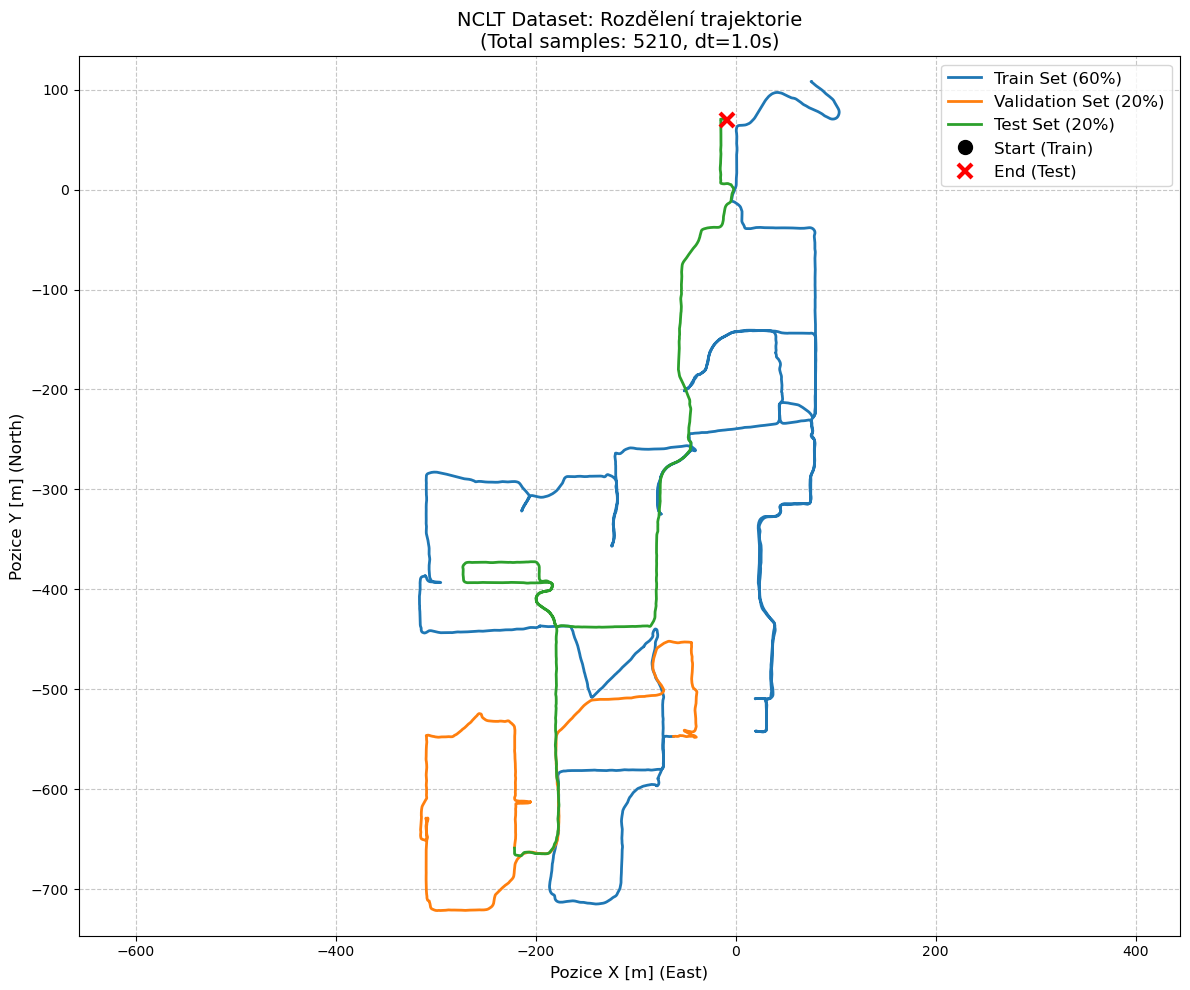

In [5]:
import matplotlib.pyplot as plt

# === VIZUALIZACE ROZDĚLENÍ DATASETU ===

plt.figure(figsize=(12, 10))

# 1. Vykreslení Trénovací části
# Musíme převést tenzory zpět na numpy (a pro jistotu na CPU, kdyby byly na GPU)
plt.plot(train_target[:, 0].cpu().numpy(), 
         train_target[:, 2].cpu().numpy(), 
         label='Train Set (60%)', color='#1f77b4', linewidth=2)

# 2. Vykreslení Validační části
plt.plot(val_target[:, 0].cpu().numpy(), 
         val_target[:, 2].cpu().numpy(), 
         label='Validation Set (20%)', color='#ff7f0e', linewidth=2)

# 3. Vykreslení Testovací části
plt.plot(test_target[:, 0].cpu().numpy(), 
         test_target[:, 2].cpu().numpy(), 
         label='Test Set (20%)', color='#2ca02c', linewidth=2)

# Zvýraznění začátku a konce
plt.plot(train_target[0, 0].cpu(), train_target[0, 2].cpu(), 'ko', markersize=10, label='Start (Train)')
plt.plot(test_target[-1, 0].cpu(), test_target[-1, 2].cpu(), 'rx', markersize=10, markeredgewidth=3, label='End (Test)')

# Formátování grafu
plt.title(f'NCLT Dataset: Rozdělení trajektorie\n(Total samples: {N_samples}, dt={DT}s)', fontsize=14)
plt.xlabel('Pozice X [m] (East)', fontsize=12)
plt.ylabel('Pozice Y [m] (North)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')  # Důležité: Aby mapa nebyla deformovaná

plt.tight_layout()
plt.show()

# Model definition

In [6]:
import torch
import math
import Systems # Předpokládám, že toto je tvůj modul s třídou DynamicSystem

# Nastavení zařízení
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################
### Design Parameters ###
### (Dle autorů)      ###
#########################

# 1. Rozměry
# Stav: [px, vx, py, vy] (Všimni si pořadí!)
m = 4 
n = 4 
delta_t = 1.0 # Sampling NCLT datasetu

# 2. Dynamika (F)
# x_{t+1} = x_t + v_t * dt
# v_{t+1} = v_t
F_dim = torch.tensor([[1.0, delta_t],
                      [0.0, 1.0]])

# Vytvoření 4x4 matice pro X a Y osy
# Výsledek je blokově diagonální, což znamená pořadí stavů: [px, vx, py, vy]
F_design = torch.block_diag(F_dim, F_dim).float()

# 3. Měření (H)
# Měříme vše: [px, vx, py, vy]
H_design = torch.eye(n).float()

# 4. Šum procesu (Q)
# Autoři definují Q diagonálně závislé na čase
lambda_q_mod = 1.0
Q_dim = torch.diagflat(torch.tensor([delta_t, delta_t]))
Q_design = (lambda_q_mod**2) * torch.block_diag(Q_dim, Q_dim).float()

# 5. Šum měření (R) - TOTO JE KLÍČOVÉ PRO REPLIKACI
# 700 = Obrovská chyba polohy (GPS) -> Filtr ji bude potlačovat
# 0.01 = Malá chyba rychlosti (Odometrie) -> Filtr jí bude věřit
# Pořadí odpovídá stavům: [Pos_X, Vel_X, Pos_Y, Vel_Y]
R_design = torch.tensor([[700.0, 0.0,   0.0,   0.0],
                         [0.0,   0.01,  0.0,   0.0],
                         [0.0,   0.0,   700.0, 0.0],
                         [0.0,   0.0,   0.0,   0.01]]).float()

# 6. Počáteční podmínky
# Autoři začínají na nule
m1x_0 = torch.zeros(m, 1).float()      # Mean
m2x_0 = torch.eye(m).float() * 1e-5

print("\nInicializuji systém dle parametrů KalmanNet (Author's replication)...")
print(f"Dimenze stavu: {m}, Dimenze měření: {n}")
print(f"R (diagonal): {torch.diagonal(R_design)}")

# === INICIALIZACE SYSTÉMŮ ===

# Sys True (Generativní model - pokud bychom generovali syntetická data)
# Pro NCLT data se toto tolik nepoužije (data načítáme), ale pro konzistenci nastavíme stejně.
sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

# Sys Model (To, co ví KalmanNet/Filtr)
sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

print("... Systémy inicializovány.")
print("POZOR: Tento model očekává pořadí stavů [px, vx, py, vy].")


Inicializuji systém dle parametrů KalmanNet (Author's replication)...
Dimenze stavu: 4, Dimenze měření: 4
R (diagonal): tensor([7.0000e+02, 1.0000e-02, 7.0000e+02, 1.0000e-02])
... Systémy inicializovány.
POZOR: Tento model očekává pořadí stavů [px, vx, py, vy].


In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# === 1. KONFIGURACE ===
TRAIN_SEQ_LEN = 50    # Délka sekvence pro RNN
VAL_SEQ_LEN = 200
TEST_SEQ_LEN = n_test
STRIDE = 10     # Posun okna (pro trénink s překryvem)
BATCH_SIZE = 128 # Velikost dávky

def create_sequences(X, Y, seq_len, stride=1):
    """
    Rozseká dlouhé tenzory [Total_Len, Dim] na sekvence [N_seq, Seq_Len, Dim].
    """
    xs = []
    ys = []
    num_samples = X.shape[0]
    
    for i in range(0, num_samples - seq_len + 1, stride):
        x_seq = X[i : i+seq_len, :]
        y_seq = Y[i : i+seq_len, :]
        xs.append(x_seq)
        ys.append(y_seq)
        
    if len(xs) == 0:
        return torch.empty(0, seq_len, X.shape[1]), torch.empty(0, seq_len, Y.shape[1])
        
    return torch.stack(xs), torch.stack(ys)

def clean_sequences(X_seq, Y_seq, name="Dataset"):
    """
    Filtruje sekvence, které obsahují jakékoliv NaN nebo Inf hodnoty.
    """
    if X_seq.numel() == 0:
        print(f"⚠️ {name}: Prázdný vstup!")
        return X_seq, Y_seq

    # Zkontrolujeme NaN/Inf pro každou sekvenci zvlášť
    # X_seq shape: [N, Seq_Len, Dim] -> reshape na [N, -1] pro kontrolu celého řádku
    is_nan_x = torch.isnan(X_seq).reshape(X_seq.shape[0], -1).any(dim=1)
    is_inf_x = torch.isinf(X_seq).reshape(X_seq.shape[0], -1).any(dim=1)
    
    is_nan_y = torch.isnan(Y_seq).reshape(Y_seq.shape[0], -1).any(dim=1)
    is_inf_y = torch.isinf(Y_seq).reshape(Y_seq.shape[0], -1).any(dim=1)
    
    # Maska vadných dat (pokud je chyba v X nebo v Y)
    invalid_mask = is_nan_x | is_inf_x | is_nan_y | is_inf_y
    
    # Vybereme jen ta dobrá
    valid_mask = ~invalid_mask
    
    X_clean = X_seq[valid_mask]
    Y_clean = Y_seq[valid_mask]
    
    n_dropped = invalid_mask.sum().item()
    if n_dropped > 0:
        print(f"⚠️ {name}: Odstraněno {n_dropped} vadných sekvencí (NaN/Inf). Zbývá: {len(X_clean)}")
    else:
        print(f"✅ {name}: Data jsou čistá. ({len(X_clean)} sekvencí)")
        
    return X_clean, Y_clean

print("--- ZPRACOVÁNÍ DAT ---")

# === 2. TVORBA SEKVENCÍ A PŘETYPOVÁNÍ ===
# Používáme .float() hned zde, abychom vyřešili Double vs Float error
print("Generuji sekvence...")
train_X_raw, train_Y_raw = create_sequences(train_target.float(), train_input.float(), TRAIN_SEQ_LEN, STRIDE)
val_X_raw, val_Y_raw = create_sequences(val_target.float(), val_input.float(), VAL_SEQ_LEN, VAL_SEQ_LEN)
test_X_raw, test_Y_raw = create_sequences(test_target.float(), test_input.float(), TEST_SEQ_LEN, TEST_SEQ_LEN)

# === 3. ČIŠTĚNÍ DAT (NAN/INF FILTER) ===
print("\nFiltruji NaN hodnoty...")
train_X_seq, train_Y_seq = clean_sequences(train_X_raw, train_Y_raw, "Train")
val_X_seq, val_Y_seq = clean_sequences(val_X_raw, val_Y_raw, "Val")
test_X_seq, test_Y_seq = clean_sequences(test_X_raw, test_Y_raw, "Test")

# === 4. VYTVOŘENÍ DATALOADERŮ ===
print("\nVytvářím DataLoadery...")
# Train: Shuffle=True
train_dataset = TensorDataset(train_X_seq, train_Y_seq)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Val/Test: Shuffle=False
val_dataset = TensorDataset(val_X_seq, val_Y_seq)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(test_X_seq, test_Y_seq)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ HOTOVO. Připraveno k tréninku.")
print(f"Batch shape: {next(iter(train_loader))[0].shape}")

--- ZPRACOVÁNÍ DAT ---
Generuji sekvence...

Filtruji NaN hodnoty...
⚠️ Train: Odstraněno 1 vadných sekvencí (NaN/Inf). Zbývá: 307
✅ Val: Data jsou čistá. (5 sekvencí)
✅ Test: Data jsou čistá. (1 sekvencí)

Vytvářím DataLoadery...

✅ HOTOVO. Připraveno k tréninku.
Batch shape: torch.Size([128, 50, 4])


In [9]:
import random
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Konfigurace sítě
rkn_architecture_config = {
    'nb_layer_FC1': 1,
    'FC1_mult': 10,
    'nbr_GRU': 1,
    'hidden_size_mult': 10,
    'nb_layer_FC2': 1,
    'FC2_mult': 20,
}

model_config = {
    "config": rkn_architecture_config,
    "weight_factor": 0.1,         
    "returns_covariance": True    
}

# Nastavení seedu pro čistý start
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("="*80)
print("INICIALIZACE MODELU RKN (Pro 4D Systém)")
print("="*80)

state_rkn = StateRecursiveKalmanNet(
    sys_model,
    device=device,
    **model_config
).to(device)


# ==============================================================================
# FÁZE 1: STABILIZACE (Pouze MSE)
# Zde se síť učí přežít extrémní R=700 a najít správnou polohu
# ==============================================================================
print("\n" + "="*80)
print("🚀 FÁZE 1: Trénink Polohy (MSE Loss) - Zahřívání sítě")
print("="*80)

train_config_phase1 = {
    "epochs": 50,               # Stačí 50 epoch na "zorientování se"
    "lr": 1e-3,
    "clip_grad": 1.0,           # Přísnější clipping proti výbuchům z R=700
    "early_stopping_patience": 15,
    "use_nll_loss": False       # TADY MUSÍ BÝT FALSE!
}

results_phase1 = train_RKN(
    model=state_rkn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    **train_config_phase1
)

# ==============================================================================
# FÁZE 2: KALIBRACE NEJISTOTY ANEES (NLL Loss)
# Nyní je chyba polohy malá, dělení P už nezpůsobí nekonečno
# ==============================================================================
print("\n" + "="*80)
print("🚀 FÁZE 2: Trénink Kovariance (NLL Loss) - Cílíme na ANEES ~4.0")
print("="*80)

train_config_phase2 = {
    "epochs": 100,               
    "lr": 1e-4,                 # 10x pomalejší učení, abychom nezničili Fázi 1
    "clip_grad": 1.0,
    "early_stopping_patience": 20,
    "use_nll_loss": True        # TADY ZAPÍNÁME NLL A UČÍME P!
}

results_phase2 = train_RKN(
    model=results_phase1['final_model'], # Bereme natrénovaný model z Fáze 1!
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    **train_config_phase2
)

trained_model = results_phase2['final_model']

# ==============================================================================
# VÝSLEDKY
# ==============================================================================
print("\n" + "="*80)
print("TRÉNINK DOKONČEN - FINÁLNÍ VÝSLEDKY Z NEJLEPŠÍHO MODELU")
print("="*80)
print(f"Nejlepší model byl nalezen v epoše (Fáze 2): {results_phase2['best_epoch']}")
print("--- Metriky odpovídající tomuto nejlepšímu modelu ---")
print(f"  MSE na validační sadě:       {results_phase2['best_val_mse']:.4f}")
print(f"  Validační Loss (NLL):        {results_phase2['best_val_loss']:.4f}")
print("="*80)
print("Dimenze stavu (m) je 4, ideální ANEES by měl být blízko 4.0.")

INICIALIZACE MODELU RKN (Pro 4D Systém)

🚀 FÁZE 1: Trénink Polohy (MSE Loss) - Zahřívání sítě
🚀 START RKN Training (Epochs: 50, LR: 0.001, NLL Loss: False)
Epoch: 1/50 | Train MSE: 238.9952 | Val MSE: 71.0631 | LR: 1.00e-03
  >>> Optimal idx: 1 | Optimal Val Loss: 71.0631 <<<
Epoch: 2/50 | Train MSE: 325.9938 | Val MSE: 60.2627 | LR: 1.00e-03
  >>> Optimal idx: 2 | Optimal Val Loss: 60.2627 <<<
Epoch: 3/50 | Train MSE: 36.0749 | Val MSE: 1089581696.0000 | LR: 1.00e-03
Epoch: 4/50 | Train MSE: 74.0257 | Val MSE: 14.8523 | LR: 1.00e-03
  >>> Optimal idx: 4 | Optimal Val Loss: 14.8523 <<<
Epoch: 5/50 | Train MSE: 7.4731 | Val MSE: 19.8550 | LR: 1.00e-03
Epoch: 6/50 | Train MSE: 2.5570 | Val MSE: 341.5995 | LR: 1.00e-03
Epoch: 7/50 | Train MSE: 2.9171 | Val MSE: 3.4747 | LR: 1.00e-03
  >>> Optimal idx: 7 | Optimal Val Loss: 3.4747 <<<
Epoch: 8/50 | Train MSE: 1.7027 | Val MSE: 6.1991 | LR: 1.00e-03
Epoch: 9/50 | Train MSE: 1.2305 | Val MSE: 6.7021 | LR: 1.00e-03
Epoch: 10/50 | Train MSE: 0

In [ ]:
if False:
    import torch
    import os

    # Protože jsi trénink přerušil, nemáme slovník s metrikami automaticky.
    # Musíme uložit přímo model 'state_knet'.

    # 1. Definuj cestu (Metriky si do názvu musíš dopsat ručně podle toho, co jsi viděl v logu naposledy,
    # nebo použij obecný název, abys o model nepřišel).
    save_path = 'best_BayesianKalmanNet_linear_velocity_integration.pth'

    # Pokud si pamatuješ hodnoty z logu (např. ANEES 23.5), můžeš je tam dopsat ručně:
    # save_path = 'best_kalmannet_nclt_sensor_fusion_ANEES23.57_MSE8.17_interrupted.pth'

    # 2. Uložení
    # DŮLEŽITÉ: Voláme .state_dict() přímo na objektu state_knet (nebo trained_knet, pokud jsi ho přiřadil)
    # Nepoužíváme závorky ['final_model'], protože state_knet UŽ JE ten model.
    torch.save(state_knet.state_dict(), save_path)

    print(f"\n✅ Záchrana modelu úspěšná! Uloženo do: {save_path}")

if False:
    import os
    # trained_knet = state_knet 
    # Přístup k metrikám ve slovníku je správně (přes závorky [])
    print(f"   -> Best ANEES: {trained_knet['best_val_anees']:.4f}")
    print(f"   -> Best MSE:   {trained_knet['best_val_mse']:.4f}")
    save_path = f'best_kalmanFormer_nclt_sensor_fusion_ANEES{trained_knet["best_val_anees"]:.4f}_MSE{trained_knet["best_val_mse"]:.4f}_nejlepsi_test_vysledky.pth '

    # OPRAVA: Musíš vytáhnout model ze slovníku pomocí klíče 'final_model'
    # A teprve na něm zavolat .state_dict()
    torch.save(trained_knet['final_model'].state_dict(), save_path)

    print(f"\n✅ Model úspěšně uložen do: {save_path}")


In [10]:
import torch
import torch.nn.functional as F
import numpy as np
import Filters  # Tvůj modul s filtry
from utils import utils # Tvůj modul pro ANEES

# ==============================================================================
# 0. KONFIGURACE
# ==============================================================================

# Příprava RKN modelu
try:
    # Předpokládáme, že model se jmenuje state_rkn nebo trained_model
    trained_model_rkn = state_rkn 
    # DŮLEŽITÉ: RKN je deterministický, takže při vyhodnocení musí být v eval()
    trained_model_rkn.eval() 
    print("INFO: Recursive KalmanNet (RKN) připraven.")
except NameError:
    raise NameError("Chyba: Proměnná 'state_rkn' neexistuje. Spusťte nejprve trénink RKN.")

# Inicializace klasických filtrů pro srovnání
print("Inicializuji EKF, UKF a PF...")
ekf_filter = Filters.ExtendedKalmanFilter(sys_model)
ukf_filter = Filters.UnscentedKalmanFilter(sys_model)
pf_filter = Filters.ParticleFilter(sys_model, num_particles=1000) # Sníženo z 10k na 1k pro rozumnou rychlost testu

# ==============================================================================
# 1. VYHODNOCOVACÍ SMYČKA
# ==============================================================================
metrics = {
    'RKN':  {'mse': [], 'anees': []}, # Přejmenováno z BKN na RKN
    'EKF':  {'mse': [], 'anees': []},
    'UKF':  {'mse': [], 'anees': []},
    'PF':   {'mse': [], 'anees': []}
}

traj_idx = 0
total_trajectories = len(test_loader.dataset)

print(f"\nVyhodnocuji {total_trajectories} sekvencí...")

with torch.no_grad():
    for batch_data in test_loader:
        # Robustní rozbalení dat (x, y, u)
        if len(batch_data) == 3:
            x_true_batch, y_meas_batch, u_input_batch = batch_data
        else:
            x_true_batch, y_meas_batch = batch_data

        batch_size = x_true_batch.shape[0]
        
        for i in range(batch_size):
            traj_idx += 1
            
            # Data jedné trajektorie
            y_seq = y_meas_batch[i].to(device)    # [T, Obs]
            x_true = x_true_batch[i].to(device)   # [T, State]
            seq_len = y_seq.shape[0]

            # Inicializace (Ground Truth)
            init_state_row = x_true[0, :].unsqueeze(0) 
            init_state_col = x_true[0, :].unsqueeze(1) 
            
            # ---------------------------------------------------------
            # 1. Recursive KalmanNet (RKN) - DETERMINISTICKÁ LOGIKA
            # ---------------------------------------------------------
            trained_model_rkn.reset(batch_size=1, initial_state=init_state_row)
            
            rkn_preds_x = []
            rkn_preds_P = []
            
            for t in range(1, seq_len):
                y_t = y_seq[t].unsqueeze(0) # Tvar [1, Obs_Dim]
                
                # RKN vrací (x_filtered, P_filtered, reg_loss)
                step_output = trained_model_rkn.step(y_t)
                x_est = step_output[0]
                P_est = step_output[1]
                
                # Ostraníme batch dimenzi pro uložení do listu
                rkn_preds_x.append(x_est.squeeze(0))
                
                # Ošetření dimenzí matice P (pro jistotu)
                p_tensor = P_est.squeeze(0)
                while p_tensor.dim() < 2:
                    p_tensor = p_tensor.unsqueeze(-1)
                rkn_preds_P.append(p_tensor)
            
            # Složení do tensorů [T-1, Dim] a [T-1, Dim, Dim]
            x_rkn_tensor = torch.stack(rkn_preds_x, dim=0)
            P_rkn_tensor = torch.stack(rkn_preds_P, dim=0)
            
            # Uložení metrik RKN (porovnáváme od t=1 do konce)
            metrics['RKN']['mse'].append(F.mse_loss(x_rkn_tensor, x_true[1:]).item())
            metrics['RKN']['anees'].append(utils.calculate_anees_vectorized(
                x_true[1:].unsqueeze(0), 
                x_rkn_tensor.unsqueeze(0), 
                P_rkn_tensor.unsqueeze(0)
            ))

            # ---------------------------------------------------------
            # 2. Klasické Filtry (EKF, UKF, PF)
            # ---------------------------------------------------------
            try:
                # EKF
                res_ekf = ekf_filter.process_sequence(y_seq, Ex0=init_state_col, P0=sys_model.P0)
                metrics['EKF']['mse'].append(F.mse_loss(res_ekf['x_filtered'][1:], x_true[1:]).item())
                metrics['EKF']['anees'].append(utils.calculate_anees_vectorized(
                    x_true[1:].unsqueeze(0), res_ekf['x_filtered'][1:].unsqueeze(0), res_ekf['P_filtered'][1:].unsqueeze(0)))
                
                # UKF
                res_ukf = ukf_filter.process_sequence(y_seq, Ex0=init_state_col, P0=sys_model.P0)
                metrics['UKF']['mse'].append(F.mse_loss(res_ukf['x_filtered'][1:], x_true[1:]).item())
                metrics['UKF']['anees'].append(utils.calculate_anees_vectorized(
                    x_true[1:].unsqueeze(0), res_ukf['x_filtered'][1:].unsqueeze(0), res_ukf['P_filtered'][1:].unsqueeze(0)))
                
                # PF
                res_pf = pf_filter.process_sequence(y_seq, Ex0=init_state_col, P0=sys_model.P0)
                metrics['PF']['mse'].append(F.mse_loss(res_pf['x_filtered'][1:], x_true[1:]).item())
                metrics['PF']['anees'].append(utils.calculate_anees_vectorized(
                    x_true[1:].unsqueeze(0), res_pf['x_filtered'][1:].unsqueeze(0), res_pf['P_filtered'][1:].unsqueeze(0)))
            
            except Exception as e:
                # print(f"Chyba filtru: {e}")
                pass 

            if traj_idx % 20 == 0:
                print(f"  ... {traj_idx} hotovo")

# ==============================================================================
# 2. FINÁLNÍ VÝPIS
# ==============================================================================
def avg(l): return np.mean([x for x in l if not np.isnan(x)]) if len(l)>0 else np.nan

print("\n" + "="*90)
print(f"SROVNÁNÍ RKN vs KLASICKÉ FILTRY")
print("="*90)
print(f"{'Model':<25} | {'MSE':<15} | {'RMSE [m]':<15} | {'ANEES':<15}")
print("-" * 90)

for name in ['RKN', 'EKF', 'UKF', 'PF']:
    m = avg(metrics[name]['mse'])
    a = avg(metrics[name]['anees'])
    rmse = np.sqrt(m) if not np.isnan(m) else np.nan
    
    print(f"{name:<25} | {m:<15.4f} | {rmse:<15.4f} | {a:<15.4f}")

print("="*90)
print(f"Pozn: Ideální ANEES pro state_dim={sys_model.state_dim} je cca {sys_model.state_dim:.1f}.")

INFO: Recursive KalmanNet (RKN) připraven.
Inicializuji EKF, UKF a PF...

Vyhodnocuji 1 sekvencí...


Processing sequence PF: 100%|██████████| 1041/1041 [00:01<00:00, 607.47it/s]


SROVNÁNÍ RKN vs KLASICKÉ FILTRY
Model                     | MSE             | RMSE [m]        | ANEES          
------------------------------------------------------------------------------------------
RKN                       | 1.9170          | 1.3845          | 5.5790         
EKF                       | 7.0031          | 2.6463          | 3.0129         
UKF                       | 7.0030          | 2.6463          | 3.0128         
PF                        | 17.6923         | 4.2062          | 15.4696        
Pozn: Ideální ANEES pro state_dim=4 je cca 4.0.


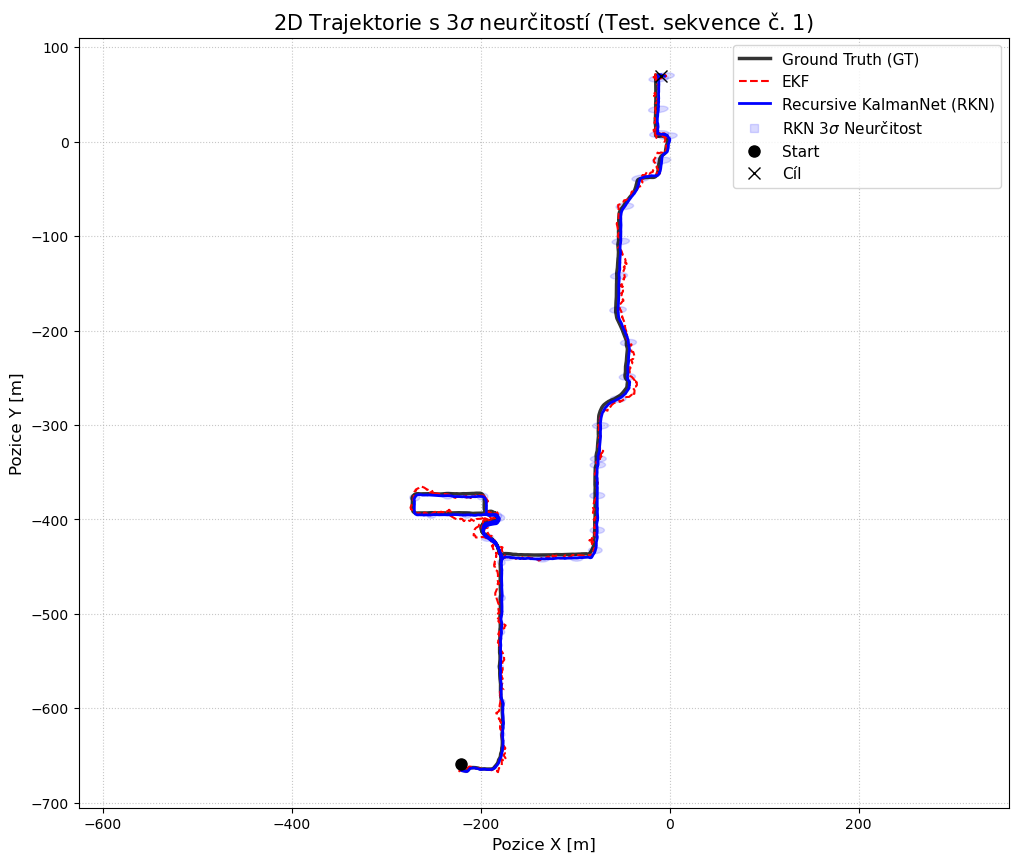

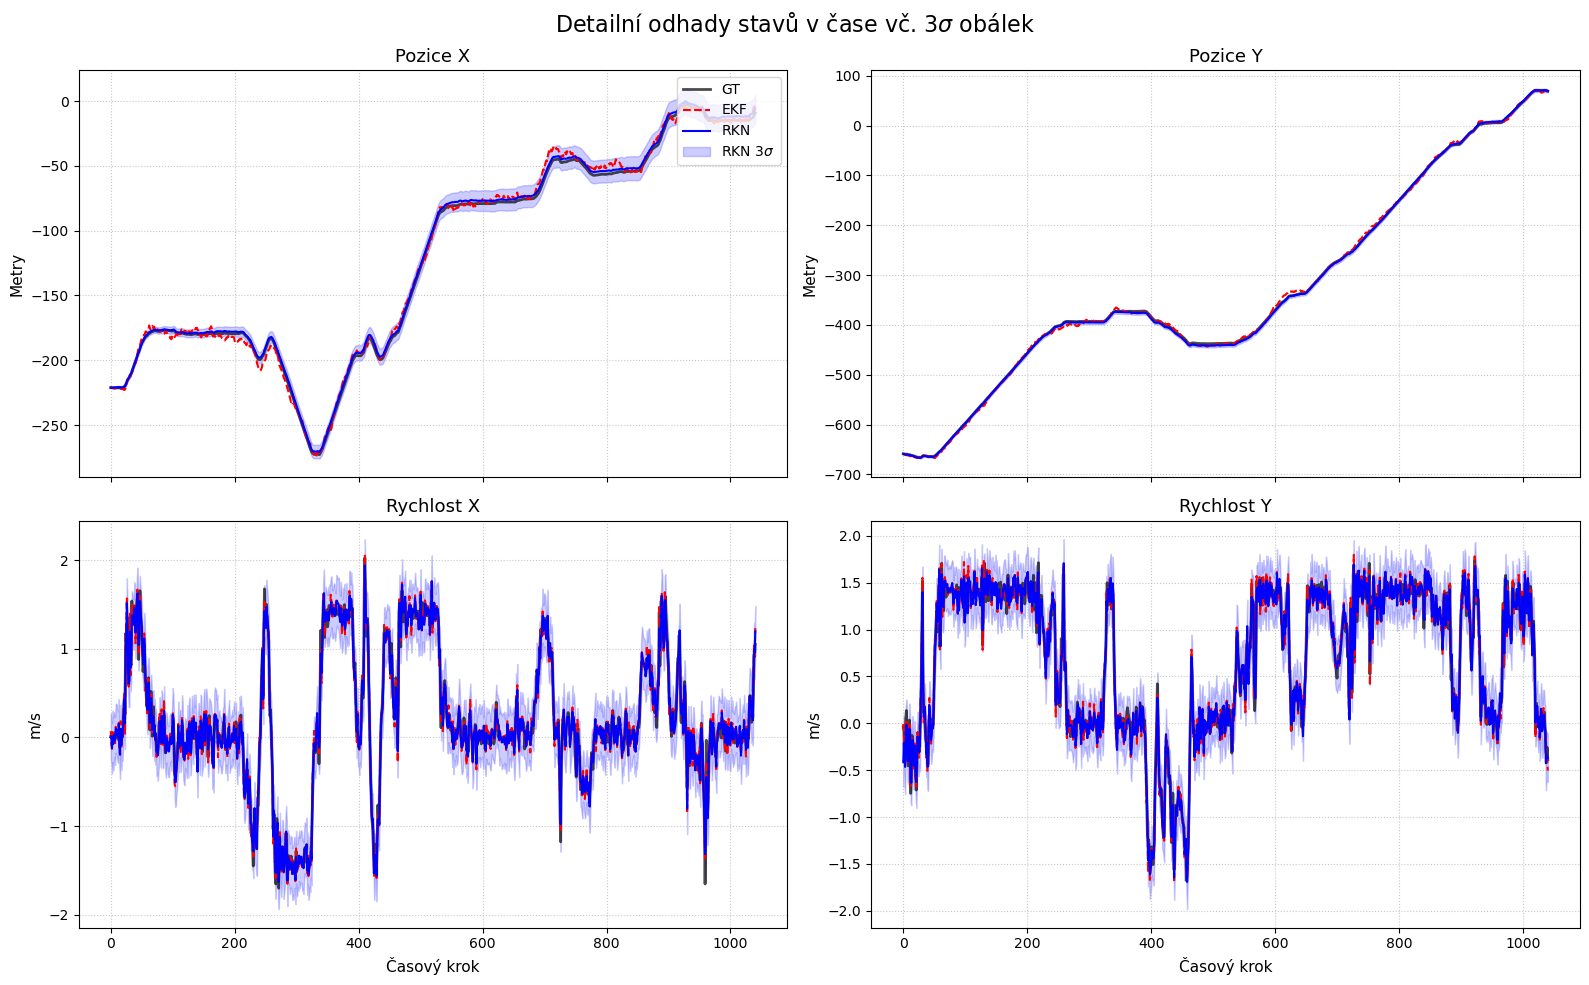

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

# === VIZUALIZACE POSLEDNÍ TESTOVACÍ TRAJEKTORIE VČETNĚ NEURČITOSTI ===

# 1. Převod tenzorů na NumPy pole (z poslední iterace smyčky)
# Odřezáváme t=0 [1:], abychom měli stejnou délku jako predikce
gt_np = x_true[1:].cpu().numpy()
rkn_x_np = x_rkn_tensor.cpu().numpy()
rkn_P_np = P_rkn_tensor.cpu().numpy()
ekf_x_np = res_ekf['x_filtered'][1:].cpu().numpy()
ukf_x_np = res_ukf['x_filtered'][1:].cpu().numpy()

# Časová osa (kroky)
time_steps = np.arange(gt_np.shape[0])

# Indexy stavů: [px, vx, py, vy]
idx_px, idx_vx, idx_py, idx_vy = 0, 1, 2, 3

# Výpočet směrodatných odchylek (odmocnina z diagonály matice P)
rkn_std_px = np.sqrt(rkn_P_np[:, idx_px, idx_px])
rkn_std_vx = np.sqrt(rkn_P_np[:, idx_vx, idx_vx])
rkn_std_py = np.sqrt(rkn_P_np[:, idx_py, idx_py])
rkn_std_vy = np.sqrt(rkn_P_np[:, idx_vy, idx_vy])


# ====================================================================
# GRAF 1: 2D TRAJEKTORIE (MAPA S KOVARIANČNÍMI ELIPSAMI)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_title(f"2D Trajektorie s $3\sigma$ neurčitostí (Test. sekvence č. {traj_idx})", fontsize=15)

# Ground Truth a Filtry
ax.plot(gt_np[:, idx_px], gt_np[:, idx_py], 'k-', linewidth=2.5, label='Ground Truth (GT)', alpha=0.8)
ax.plot(ekf_x_np[:, idx_px], ekf_x_np[:, idx_py], 'r--', linewidth=1.5, label='EKF')
ax.plot(rkn_x_np[:, idx_px], rkn_x_np[:, idx_py], 'b-', linewidth=2, label='Recursive KalmanNet (RKN)')

# Vykreslení 3-sigma elips (např. každých 20 kroků, aby graf nebyl přeplácaný)
step_size = max(1, len(rkn_x_np) // 40) # Zhruba 40 elips na celou trasu
for t in range(0, len(rkn_x_np), step_size):
    # Vytažení 2x2 sub-kovarianční matice pro pozici X a Y
    cov_2d = rkn_P_np[t][[[idx_px], [idx_py]], [[idx_px, idx_py]]]
    
    # Výpočet vlastních čísel a vektorů pro elipsu
    eigenvals, eigenvecs = np.linalg.eigh(cov_2d)
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    
    # 3-sigma šířka a výška
    width, height = 2 * 3 * np.sqrt(np.maximum(eigenvals, 0))
    
    # Přidání elipsy do grafu
    ellip = Ellipse(xy=(rkn_x_np[t, idx_px], rkn_x_np[t, idx_py]), 
                    width=width, height=height, angle=angle, 
                    facecolor='blue', edgecolor='blue', alpha=0.15)
    ax.add_patch(ellip)

# Dummy bod pro legendu elipsy
ax.plot([], [], 's', color='blue', alpha=0.15, label='RKN $3\sigma$ Neurčitost')

# Start a Cíl
ax.plot(gt_np[0, idx_px], gt_np[0, idx_py], 'ko', markersize=8, label='Start')
ax.plot(gt_np[-1, idx_px], gt_np[-1, idx_py], 'kx', markersize=8, label='Cíl')

ax.set_xlabel("Pozice X [m]", fontsize=12)
ax.set_ylabel("Pozice Y [m]", fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, linestyle=':', alpha=0.7)
ax.axis('equal') # Klíčové pro správný tvar elips a mapy!
plt.show()


# ====================================================================
# GRAF 2: DETAILNÍ PRŮBĚHY STAVŮ (S 1D OBÁLKAMI)
# ====================================================================
fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle("Detailní odhady stavů v čase vč. $3\sigma$ obálek", fontsize=16)

def plot_state_with_envelope(ax, true_val, ekf_val, rkn_val, rkn_std, title, ylabel):
    ax.plot(time_steps, true_val, 'k-', linewidth=2, label='GT', alpha=0.7)
    ax.plot(time_steps, ekf_val, 'r--', linewidth=1.5, label='EKF')
    ax.plot(time_steps, rkn_val, 'b-', linewidth=1.5, label='RKN')
    
    # Přidání 3-sigma obálky pro RKN
    ax.fill_between(time_steps, 
                    rkn_val - 3 * rkn_std, 
                    rkn_val + 3 * rkn_std, 
                    color='blue', alpha=0.2, label='RKN $3\sigma$')
    
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.7)

# --- Pozice X ---
plot_state_with_envelope(axs[0, 0], gt_np[:, idx_px], ekf_x_np[:, idx_px], 
                         rkn_x_np[:, idx_px], rkn_std_px, "Pozice X", "Metry")
axs[0, 0].legend(loc='upper right')

# --- Pozice Y ---
plot_state_with_envelope(axs[0, 1], gt_np[:, idx_py], ekf_x_np[:, idx_py], 
                         rkn_x_np[:, idx_py], rkn_std_py, "Pozice Y", "Metry")

# --- Rychlost X ---
plot_state_with_envelope(axs[1, 0], gt_np[:, idx_vx], ekf_x_np[:, idx_vx], 
                         rkn_x_np[:, idx_vx], rkn_std_vx, "Rychlost X", "m/s")
axs[1, 0].set_xlabel("Časový krok", fontsize=11)

# --- Rychlost Y ---
plot_state_with_envelope(axs[1, 1], gt_np[:, idx_vy], ekf_x_np[:, idx_vy], 
                         rkn_x_np[:, idx_vy], rkn_std_vy, "Rychlost Y", "m/s")
axs[1, 1].set_xlabel("Časový krok", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Úprava mezery pro hlavní nadpis
plt.show()